In [70]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler



# Load the CSV file
file_path = 'mean_air_spectrum.csv'
df = pd.read_csv(file_path)

# Display the first few rows to understand the structure
df.head()


,Wavelength(nm),Intensity
0,195.1292,0.0
1,195.3960,0.0
2,195.6629,0.0
3,195.9298,0.0
4,196.1966,0.0


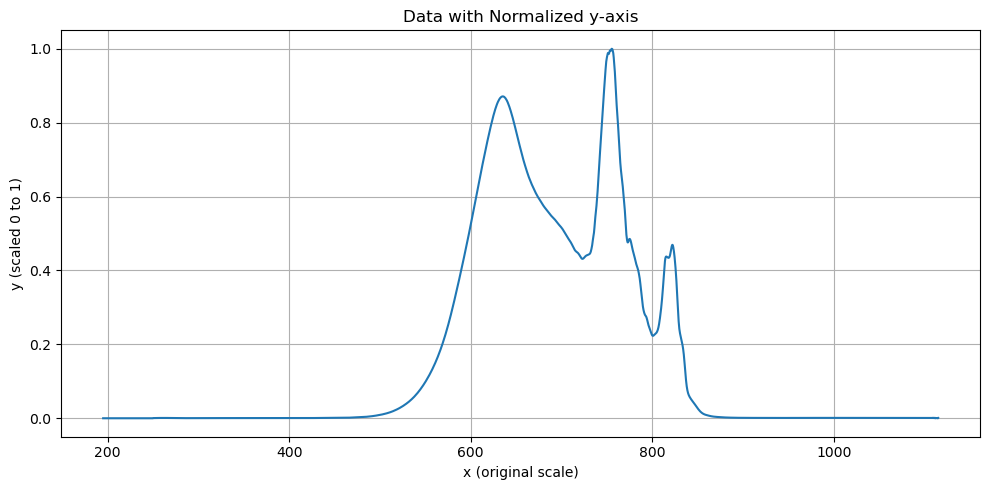

In [71]:
# Reload the CSV using tab as the delimiter
df.columns = ['Wavelength(nm)', 'Intensity']

# Normalize only the y-axis, not the x-axis
scaled_y = MinMaxScaler().fit_transform(df[['Intensity']])

# Keep original x values
x = df['Wavelength(nm)']
y = scaled_y.flatten()

# Plot with original x and scaled y
plt.figure(figsize=(10, 5))
plt.plot(x, y)
plt.title('Data with Normalized y-axis')
plt.xlabel('x (original scale)')
plt.ylabel('y (scaled 0 to 1)')
plt.grid(True)
plt.tight_layout()
plt.show()



### PART 1: Eliminating the noise beyond the required range.

In [72]:
# Re-import necessary libraries due to kernel reset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from scipy.signal import fftconvolve

# Normalize y data only
x = df['Wavelength(nm)'].values
y = MinMaxScaler().fit_transform(df[['Intensity']]).flatten()

# Define the Super-Gaussian function
def supergaussian(x, center, width, order, amplitude):
    return amplitude * np.exp(-((x - center) / (width / 2)) ** (2 * order))


tapered spectrum, created by pointwise multiplication of the original spectrum with the super-Gaussian envelope.

Allows for better drop off along the side, while filtering out the noise issues which may cause erratic frequencies

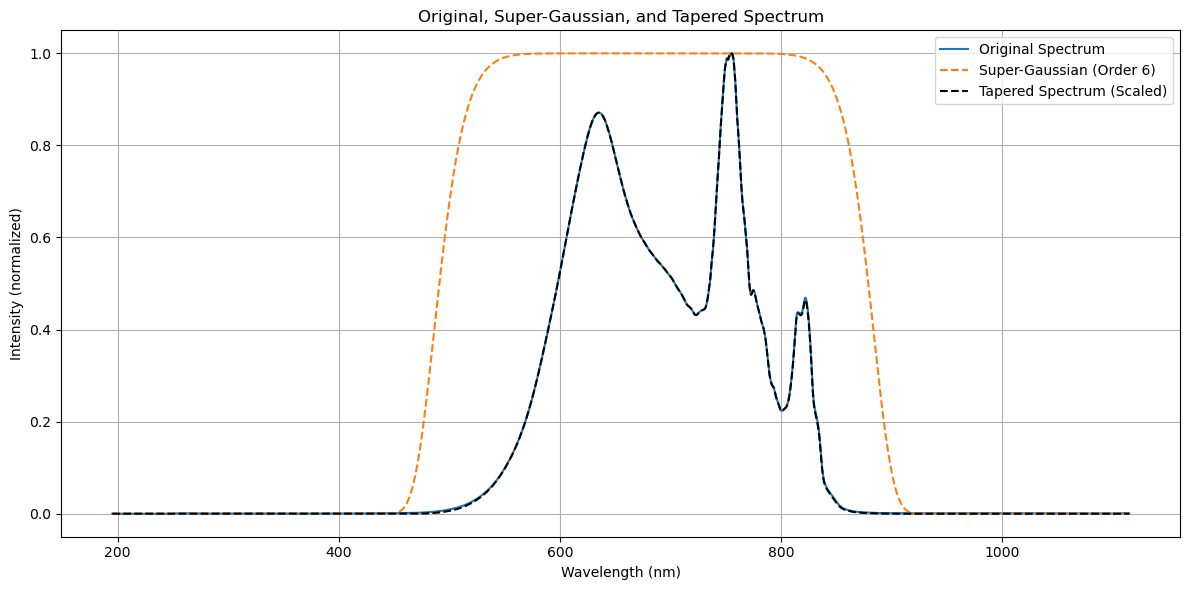

In [73]:

# Create the Super-Gaussian
center = 685
width = 400
order = 6
amplitude = 1
supergauss = supergaussian(x, center=center, width=width, order=order, amplitude=amplitude)



# Apply the supergaussian as a multiplicative mask (tapering)
tapered = y * supergauss  # Point-wise multiplication

# Normalize the tapered result between 0 and 1
tapered_scaled = MinMaxScaler().fit_transform(tapered.reshape(-1, 1)).flatten()

# Plot all three
plt.figure(figsize=(12, 6))
plt.plot(x, y, label='Original Spectrum')
plt.plot(x, supergauss, label='Super-Gaussian (Order 6)', linestyle='--')
plt.plot(x, tapered_scaled, label='Tapered Spectrum (Scaled)', linestyle='dashed', color='black')
plt.title('Original, Super-Gaussian, and Tapered Spectrum')
plt.xlabel('Wavelength (nm)')
plt.ylabel('Intensity (normalized)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


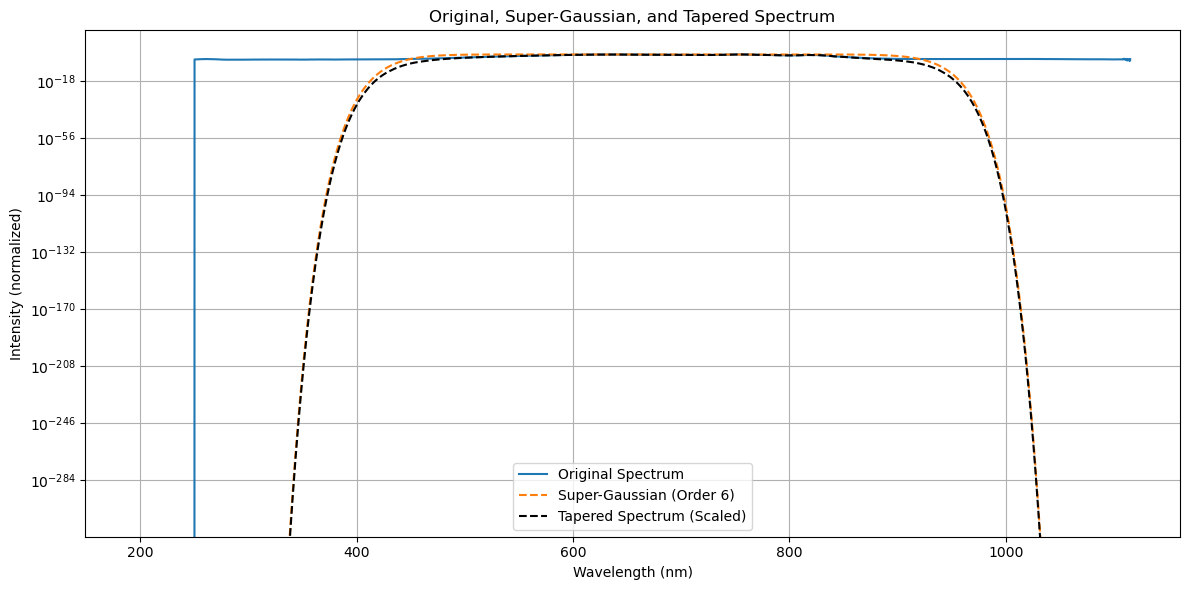

In [74]:
# Plot all three
plt.figure(figsize=(12, 6))
plt.plot(x, y, label='Original Spectrum')
plt.plot(x, supergauss, label='Super-Gaussian (Order 6)', linestyle='--')
plt.plot(x, tapered_scaled, label='Tapered Spectrum (Scaled)', linestyle='dashed', color='black')
plt.title('Original, Super-Gaussian, and Tapered Spectrum')
plt.xlabel('Wavelength (nm)')
plt.ylabel('Intensity (normalized)')
plt.yscale('log')  # Logarithmic scale for better visibility
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Combination of higher order (n=8) Gaussian with epsilon gives a sharp drop off, removes noise, and allows for easy understanding of frequency range involved in the SCG

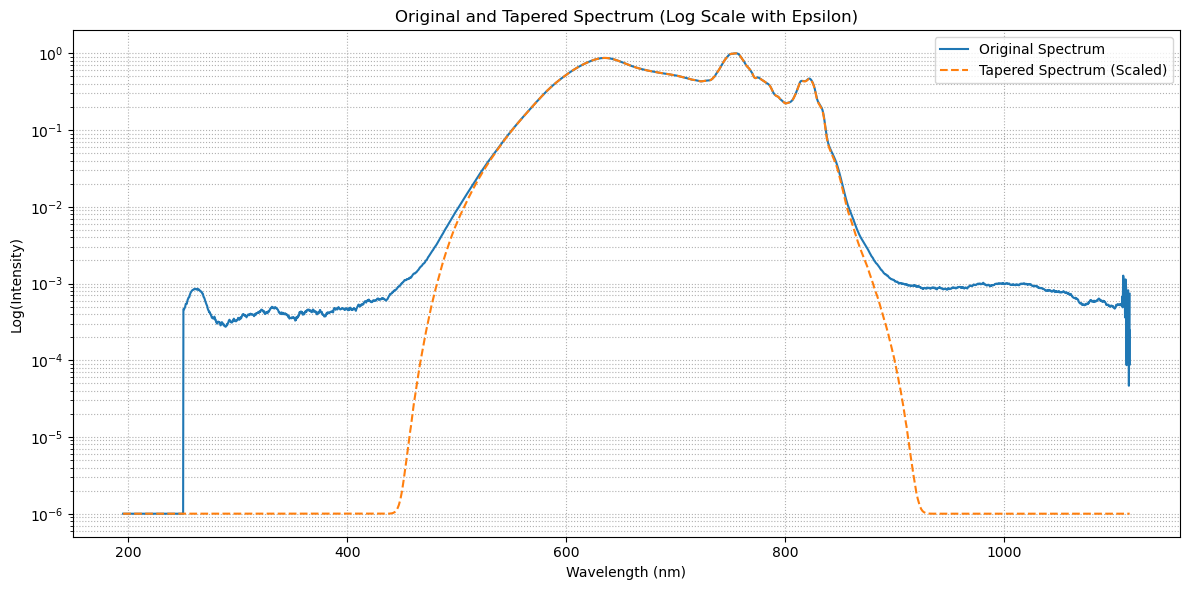

In [75]:
# Add a small epsilon to avoid log(0)
epsilon = 1e-6
y_log_safe = y + epsilon
tapered_log_safe = tapered_scaled + epsilon

# Plot with log scale on y-axis
plt.figure(figsize=(12, 6))
plt.plot(x, y_log_safe, label='Original Spectrum')
plt.plot(x, tapered_log_safe, label='Tapered Spectrum (Scaled)', linestyle='--')
plt.yscale('log')
plt.title('Original and Tapered Spectrum (Log Scale with Epsilon)')
plt.xlabel('Wavelength (nm)')
plt.ylabel('Log(Intensity)')
plt.legend()
plt.grid(True, which='both', linestyle=':')
plt.tight_layout()
plt.show()


### PART 2: Conversion from FRQ -> TIME domains using FFT

<Figure size 1200x600 with 0 Axes>

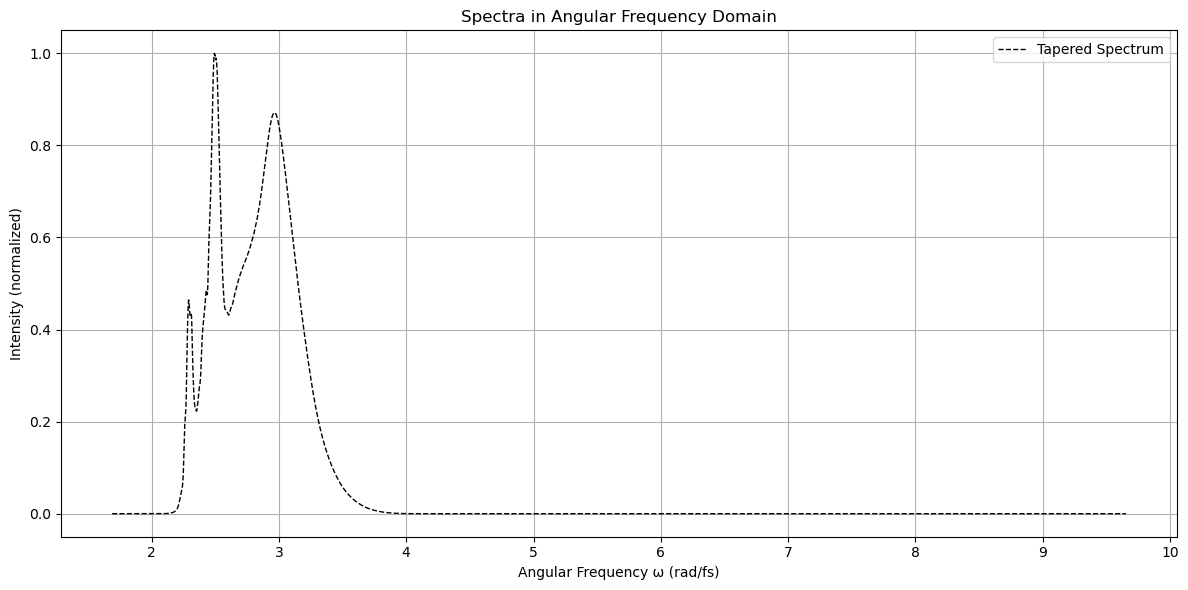

In [76]:
# Convert wavelength (nm) to angular frequency (rad/fs)
c_nm_fs = 299792458 * 1e-6  # Speed of light in nm/fs
omega = 2 * np.pi * c_nm_fs / x  # Angular frequency ω = 2πc / λ

# Sort for increasing angular frequency
sorted_indices = np.argsort(omega)
omega_sorted = omega[sorted_indices]
tapered_sorted = tapered_scaled[sorted_indices]

# Convert original (untapered) spectrum to angular frequency domain for comparison
y_sorted = y[sorted_indices]
supergauss_sorted = supergauss[sorted_indices]

# Plot in frequency domain
plt.figure(figsize=(12, 6))
# Plot original, supergaussian, and tapered spectrum in angular frequency domain
plt.figure(figsize=(12, 6))
# plt.plot(omega_sorted, y_sorted, label='Original Spectrum', color='green', linewidth=2)
# plt.plot(omega_sorted, supergauss_sorted, label='Super-Gaussian (600 nm)', linestyle='--')
plt.plot(omega_sorted, tapered_sorted, label='Tapered Spectrum', linestyle='--', color='black', linewidth=1)
plt.title('Spectra in Angular Frequency Domain')
plt.xlabel('Angular Frequency ω (rad/fs)')
plt.ylabel('Intensity (normalized)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


FFT application from omega to time should ideally happens using both positive and negative frequencies.
We isolate positive frequencies from the above spectrum, create a mirror negative axis before applying the FT.

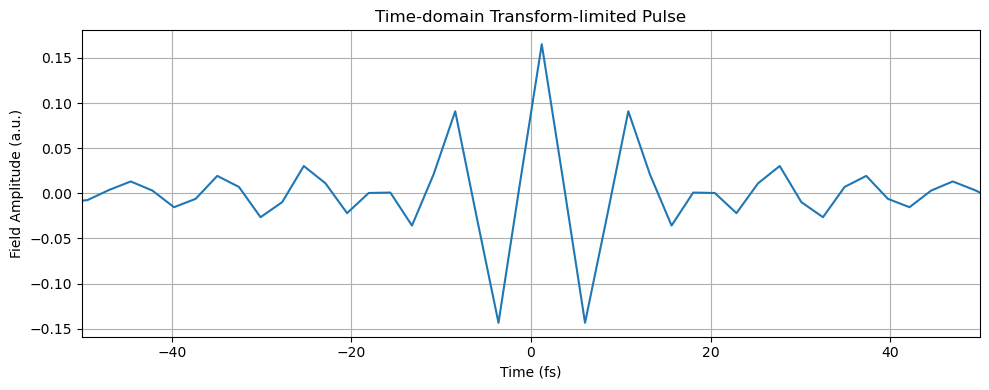

(-50.0, 50.0)

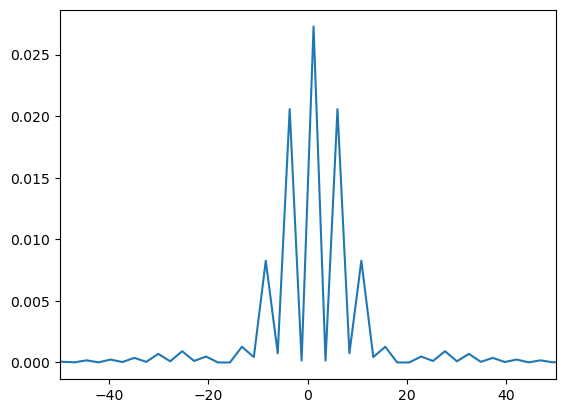

In [77]:
import numpy as np
import matplotlib.pyplot as plt

def magnitude_to_time_domain(mag_pos, omega_pos, plot_result=True):
    """
    Convert a positive-frequency-only magnitude spectrum into a time-domain signal
    assuming zero spectral phase (transform-limited).

    Parameters:
        mag_pos (np.ndarray): Magnitude spectrum at positive angular frequencies
        omega_pos (np.ndarray): Corresponding angular frequencies (rad/fs)
        num_bins (int): Total number of bins for IFFT (defines temporal resolution)
        plot_result (bool): Whether to plot the result or not

    Returns:
        t (np.ndarray): Time vector (fs), centered around 0
        E_t (np.ndarray): Real-valued time-domain electric field
    """

    N_pos = len(mag_pos)

    # Step 1: Determine number of bins
    num_bins = 2 * N_pos - 2  # Full spectrum: +ve and -ve (excluding duplicated DC)


    # Step 2: Create full symmetric spectrum (real, zero-phase)
    mag_full = np.zeros(num_bins)
    mag_full[:N_pos] = mag_pos

    # Mirror positive spectrum (excluding DC and Nyquist if even)
    mirror = mag_pos[1:N_pos-1][::-1]
    mag_full[-len(mirror):] = mirror

    # Step 3: Construct complex spectrum with zero phase
    spectrum_complex = mag_full * np.exp(0j)

    # Step 4: Inverse FFT and shift to center
    E_t_raw = np.fft.ifft(spectrum_complex)
    E_t = np.fft.ifftshift(np.real(E_t_raw))  # Center the time-domain field

    # Step 5: Time axis construction
    domega = omega_pos[1] - omega_pos[0]
    T = 2 * np.pi / domega  # Total temporal window
    dt = T / num_bins
    t = np.linspace(-T/2, T/2, num_bins)

    if plot_result:
        plt.figure(figsize=(10, 4))
        plt.plot(t, E_t)
        plt.title("Time-domain Transform-limited Pulse")
        plt.xlabel("Time (fs)")
        plt.ylabel("Field Amplitude (a.u.)")
        plt.grid(True)
        plt.xlim(-50, 50)
        plt.tight_layout()
        plt.show()
        
    return t, E_t

t, E_t = magnitude_to_time_domain(tapered_sorted, omega_sorted)

plt.plot(t, E_t ** 2)
plt.xlim(-50, 50)